# Técnicas de Diseño y Validación de Modelos · Universidad Blas Pascal
## Preparación Examen Final · Banco 2
## Regularización y búsqueda de hiperparámetros (Módulos 3, 4 y 5)

<div style="display:flex; justify-content:flex-start; margin: 8px 0 18px 0;">
  <a href="https://colab.research.google.com/github/GabrielaOjcius/Laboratorios-Tecnicas-Diseno-Validacion-Modelos/blob/main/Preparacion%20Examen%20Final/Banco2_Notebook.ipynb" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
  <span style="font-size: 0.98em;">En Colab, hac&eacute; una copia en tu Drive antes de editar.</span>
</div>

---

### Objetivo
Practicar los conceptos evaluados en la consigna del **Banco 2** del examen final: overfitting en presencia de predictores correlacionados, diferencia entre regularización L1 y L2, y comparación entre Grid Search y Random Search bajo presupuesto de cómputo limitado.

### Alineación con el examen final
Corresponde a la consigna del **Banco 2** (Módulos 3, 4 y 5) del examen final de Técnicas de Diseño y Validación de Modelos.

**Duración estimada:** 60 minutos

### Instrucciones
1. Ejecutar las celdas en orden (Entorno de ejecución → Ejecutar todo).
2. Completar las celdas de respuesta marcadas con `# ✏️ RESPONDA AQUÍ`.
3. No es necesario modificar el código, solo ejecutarlo y responder.

In [1]:
# ─── B.1. Datos de regresión con predictores correlacionados ────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

SEED = 42
rng = np.random.default_rng(SEED)

n, p = 400, 6
# Generamos predictores fuertemente correlacionados a partir de 2 factores latentes
factor1 = rng.normal(size=n)
factor2 = rng.normal(size=n)
X = np.column_stack([
    factor1 + rng.normal(scale=0.1, size=n),
    factor1 + rng.normal(scale=0.1, size=n),
    factor1 + rng.normal(scale=0.15, size=n),
    factor2 + rng.normal(scale=0.1, size=n),
    factor2 + rng.normal(scale=0.15, size=n),
    rng.normal(size=n),  # variable no correlacionada
])
true_coef = np.array([3.0, 0.0, 0.0, -2.0, 0.0, 0.5])
y = X @ true_coef + rng.normal(scale=1.0, size=n)

print('Correlación entre predictores (deberían verse bloques altos):')
print(pd.DataFrame(X).corr().round(2))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

Correlación entre predictores (deberían verse bloques altos):
      0     1     2     3     4     5
0  1.00  0.99  0.98 -0.04 -0.04  0.05
1  0.99  1.00  0.98 -0.03 -0.03  0.06
2  0.98  0.98  1.00 -0.02 -0.02  0.05
3 -0.04 -0.03 -0.02  1.00  0.98 -0.02
4 -0.04 -0.03 -0.02  0.98  1.00 -0.01
5  0.05  0.06  0.05 -0.02 -0.01  1.00


In [2]:
# ─── B.2. Regresión lineal sin regularizar: overfitting con polinomios ───────
poly = PolynomialFeatures(degree=3, include_bias=False)
Xp_train = poly.fit_transform(X_train)
Xp_test = poly.transform(X_test)

lin = LinearRegression().fit(Xp_train, y_train)
print('Regresión lineal + polinomios grado 3:')
print('  R² train = %.4f' % r2_score(y_train, lin.predict(Xp_train)))
print('  R² test  = %.4f  (brecha train/test = evidencia de sobreajuste)' % r2_score(y_test, lin.predict(Xp_test)))

Regresión lineal + polinomios grado 3:
  R² train = 0.9558
  R² test  = 0.8728  (brecha train/test = evidencia de sobreajuste)


### Pregunta 1 — Relación con overfitting (Módulo 3)
¿Qué evidencia en los resultados anteriores indica sobreajuste? ¿Cómo esperaría que la regularización (Ridge/Lasso) module ese resultado?

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

Ridge (L2): R² test = 0.9091
Lasso (L1): R² test = 0.9120
ElasticNet (L1+L2): R² test = 0.9034


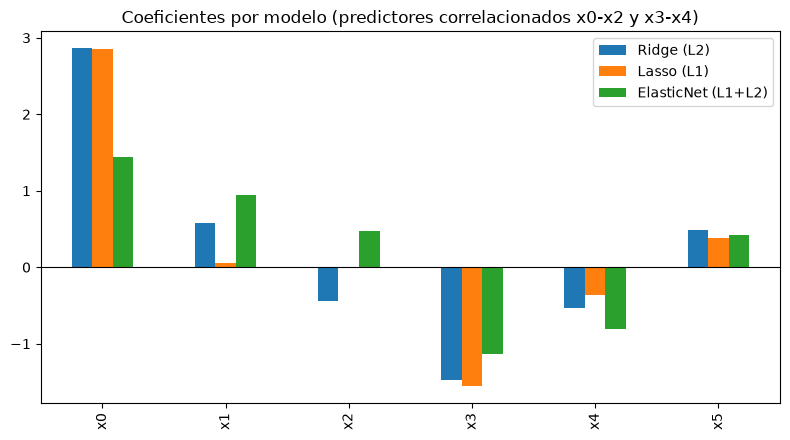

    Ridge (L2)  Lasso (L1)  ElasticNet (L1+L2)
x0       2.864       2.847               1.445
x1       0.581       0.057               0.947
x2      -0.448       0.000               0.480
x3      -1.478      -1.558              -1.132
x4      -0.534      -0.368              -0.810
x5       0.489       0.388               0.419


In [3]:
# ─── B.3. Ridge, Lasso y ElasticNet con alpha por defecto ────────────────────
modelos = {
    'Ridge (L2)': Ridge(alpha=1.0, random_state=SEED),
    'Lasso (L1)': Lasso(alpha=0.1, random_state=SEED),
    'ElasticNet (L1+L2)': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=SEED),
}

coefs = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    coefs[nombre] = modelo.coef_
    print(f'{nombre}: R² test = {r2_score(y_test, modelo.predict(X_test)):.4f}')

coef_df = pd.DataFrame(coefs, index=[f'x{i}' for i in range(p)])
coef_df.plot(kind='bar', figsize=(8, 4.5), title='Coeficientes por modelo (predictores correlacionados x0-x2 y x3-x4)')
plt.axhline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()
print(coef_df.round(3))

### Pregunta 2 — L1 vs. L2 con predictores correlacionados (Módulo 4)
Compare los coeficientes de Ridge, Lasso y ElasticNet. ¿Qué modelo produce coeficientes exactamente en cero (dispersión/selección de variables)? ¿Qué dificultad observa en Lasso frente al grupo de predictores correlacionados (x0, x1, x2)?

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

In [4]:
# ─── B.4. Grid Search vs. Random Search para elegir hiperparámetros ─────────
import time

param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}
# 5 valores x 5 valores = 25 combinaciones; con CV de 5 folds = 125 ajustes
n_combinaciones = len(param_grid['alpha']) * len(param_grid['l1_ratio'])
print('Combinaciones de Grid Search: %d' % n_combinaciones)
print('Ajustes totales con 5-fold CV: %d' % (n_combinaciones * 5))

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

t0 = time.time()
grid = GridSearchCV(ElasticNet(random_state=SEED), param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)
t_grid = time.time() - t0

t0 = time.time()
rand = RandomizedSearchCV(ElasticNet(random_state=SEED), param_grid, n_iter=8, cv=cv,
                           scoring='r2', random_state=SEED)
rand.fit(X_train, y_train)
t_rand = time.time() - t0

print('\nGrid Search   -> mejor R² CV = %.4f | params = %s | tiempo = %.3fs' % (grid.best_score_, grid.best_params_, t_grid))
print('Random Search -> mejor R² CV = %.4f | params = %s | tiempo = %.3fs (8 combinaciones probadas)' % (rand.best_score_, rand.best_params_, t_rand))

Combinaciones de Grid Search: 25
Ajustes totales con 5-fold CV: 125



Grid Search   -> mejor R² CV = 0.9350 | params = {'alpha': 0.01, 'l1_ratio': 0.9} | tiempo = 0.543s
Random Search -> mejor R² CV = 0.9346 | params = {'l1_ratio': 0.3, 'alpha': 0.01} | tiempo = 0.254s (8 combinaciones probadas)


### Pregunta 3 — Grid Search vs. Random Search (Módulo 5)
Si en lugar de 2 hiperparámetros tuviera que ajustar 8, cada uno con 5 valores posibles, ¿cuántas combinaciones evaluaría un Grid Search exhaustivo? Con el presupuesto de cómputo limitado de este ejemplo, ¿qué estrategia recomendaría (Grid Search o Random Search) y por qué?

**Respuesta:**

`# ✏️ RESPONDA AQUÍ`

---
### Checklist de autoevaluación — Banco 2
- [ ] Puedo reconocer overfitting comparando R² de train y test.
- [ ] Puedo explicar la diferencia entre penalización L1 y L2 sobre los coeficientes.
- [ ] Puedo identificar el problema de Lasso ante predictores correlacionados.
- [ ] Puedo calcular cuántas combinaciones implica un Grid Search y justificar cuándo usar Random Search.